### Configuration

In [9]:
import os
from pathlib import Path

CONFIG_PATH="../config.yaml"

req_path = Path('../requirements.txt').resolve()

if req_path.exists():
    print(f"Installing: {req_path}")
    %pip install -r "$req_path" -q
else:
    print("File requirements.txt not found")

import torch
import shutil
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler, Subset
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import pickle
from enum import IntEnum
import yaml
from dotenv import load_dotenv
from pydantic import BaseModel, Field, field_validator
from pydantic_settings import BaseSettings, SettingsConfigDict
from datetime import datetime
from scipy.spatial.distance import cdist 

# ___ config.yaml schema ___

class ModelParams(BaseModel):
    dropout_rate: float = Field(ge=0, le=1)

class TrainingParams(BaseModel):
    num_epochs: int = Field(gt=0)
    batch_size: int = Field(gt=0)
    learning_rate: float = Field(gt=0)
    checkpoint_interval: int
    patience: int
    load_checkpoint: bool
    use_scheduler: bool

class DataParams(BaseModel):
    train_split: float
    val_split: float
    gaussian_noise_mean: float
    gaussian_noise_std: float
    min_scale: float
    max_scale: float
    occlusion_prob: float
    blind_distance_value: float

class FullConfig(BaseModel):
    model: ModelParams
    training: TrainingParams
    data: DataParams


# ___ .env schema ___

class EnvSettings(BaseSettings):
    dataset_path: Path
    checkpoint_path: Path
    device: str

    use_colab: bool = False
    colab_dataset_zip_path: str | None = None
    colab_dataset_target_path: str | None = None

    model_config = SettingsConfigDict(env_file="../.env", extra="ignore")

    def _setup_colab(self):
        REPO_URL = "https://github.com/Bg735/MLVM_Project_2.7_25-26.git"
        REPO_DIR = "/content/MLVM_Project_2.7_25-26"
        if self.colab_dataset_zip_path and self.colab_dataset_target_path:
            from google.colab import drive
            drive.mount('/content/drive')

            zip_p = self.colab_dataset_zip_path
            target_p = self.colab_dataset_target_path

            samples_path = os.path.join(target_p, 'samples')

            if os.path.exists(target_p) and not os.path.exists(samples_path):
                raise FileNotFoundError(f"Could not find samples folder: {target_p}")
                shutil.rmtree(target_p)

            if not os.path.exists(samples_path):
                if not os.path.exists(zip_p):
                    raise FileNotFoundError(f"Zip archive not found in: {zip_p}")
                print(f"Extracting: {zip_p} -> {target_p}")
                os.system(f"unzip -q {zip_p} -d /content/")

            self.dataset_path = Path(target_p)

            if not os.path.exists(REPO_DIR):
                print("Cloning repository...")
                !git clone {REPO_URL} {REPO_DIR}
            else:
                print("Updating existing project...")
                %cd {REPO_DIR}
                !git pull origin main

            import sys
            if REPO_DIR not in sys.path:
                sys.path.append(REPO_DIR)

            print("Colab Setup complete.")
        else:
            raise EnvironmentError("Colab environment variables not set")

    def setup_platform(self):
        if self.use_colab:
            self._setup_colab()

    @field_validator("device")
    @classmethod
    def validate_torch_device(cls, d: str) -> str:
        d = d.lower().strip()
        if d == "cuda":
            if not torch.cuda.is_available():
                raise ValueError(f"""torch couldn't find device 'cuda' required by '{cls.model_config.get("env_file")}'.""")
        elif d == "mps":
            if not torch.backends.mps.is_available():
                raise ValueError(f"""torch couldn't find device 'mps' required by '{cls.model_config.get("env_file")}'.""")
        elif d not in ["cuda", "cpu", "mps"]:
            raise ValueError(f"""Unsupported device '{d}'. Define 'cuda', 'cpu' or 'mps' as the device in '{cls.model_config.get("env_file")}'.""")
        return d



try:
    load_dotenv()
    env = EnvSettings()

    with open(CONFIG_PATH, "r") as f:
        yaml_data = yaml.safe_load(f)
    cfg = FullConfig(**yaml_data)
except Exception as e:
    print(f"Configuration error:\n{e}")
    exit(1)

Installing: /Users/mauriziomelillo/POLITO/machine learning/PROGETTO/mlprogetto/requirements.txt

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


 ### Dataset

In [10]:
class CollisionLabel(IntEnum):
    SAFE = 0
    WARNING = 1
    CRITICAL = 2

class CollisionDataset(Dataset):
    def __init__(self, root_dir, mode, window_size=None, transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.window_size = window_size
        self.transform = transform

        self.data = []
        self.labels = []
        self.subject_indices = {}

        current_idx = 0
        samples_dir = os.path.join(root_dir, 'samples')
        subjects = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

        for s in subjects:
            self.subject_indices[s] = []
            subj_sample_path = os.path.join(samples_dir, s)
            label_type = 'static' if mode == 'static' else 'dynamic'
            subj_label_path = os.path.join(root_dir, 'labels', label_type, s)
            pkl_files = sorted(glob.glob(os.path.join(subj_sample_path, '*.pkl')))

            for pkl_f in pkl_files:
                file_name_no_ext = os.path.splitext(os.path.basename(pkl_f))[0]
                label_name = f"{file_name_no_ext}_labels.npy"
                npy_f = os.path.join(subj_label_path, label_name)

                if not os.path.exists(npy_f):
                    raise FileNotFoundError(f"Could not load label: {npy_f}")

                with open(pkl_f, 'rb') as f:
                    raw_data = pickle.load(f)

                human_seq = np.array([frame[0] for frame in raw_data])
                robot_seq = np.array([frame[1] for frame in raw_data])
                
                human_flat = human_seq.reshape(human_seq.shape[0], -1)
                robot_flat = robot_seq.reshape(robot_seq.shape[0], -1)
                
                num_frames = human_seq.shape[0]
                num_human_joints = human_seq.shape[1]
                num_robot_joints = robot_seq.shape[1]
                
                dists_seq = np.zeros((num_frames, num_human_joints * num_robot_joints))
                
                for i in range(num_frames):
                    d = cdist(human_seq[i], robot_seq[i], metric='euclidean')
                    dists_seq[i] = d.flatten()
                
                features = dists_seq
                
                # features = np.concatenate((human_flat, robot_flat, dists_seq), axis=1)
            
                #human_flat = human_seq.reshape(human_seq.shape[0], -1)
                #robot_flat = robot_seq.reshape(robot_seq.shape[0], -1)
                #features = np.concatenate((human_flat, robot_flat), axis=1)

                targets = np.load(npy_f)
                num_frames = features.shape[0]

                if self.mode == 'static':
                    for i in range(num_frames):
                        self.data.append(features[i])
                        self.labels.append(targets[i])
                        self.subject_indices[s].append(current_idx)
                        current_idx += 1

                elif self.mode == 'dynamic':
                    if window_size is None:
                        raise ValueError("Parameter window_size is required for dynamic mode")

                    for i in range(num_frames):
                        start_idx = i - window_size + 1

                        if start_idx < 0:
                            real_data = features[0: i + 1]
                            missing_count = window_size - real_data.shape[0]
                            padding = np.tile(features[0], (missing_count, 1))
                            window_x = np.concatenate((padding, real_data), axis=0)
                        else:
                            window_x = features[start_idx: i + 1]

                        self.data.append(window_x)
                        self.labels.append(targets[i])
                        self.subject_indices[s].append(current_idx)
                        current_idx += 1

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform is not None:
            x = self.transform(x)

        return x, y

    def get_indices_for_subjects(self, subject_list):
        indices = []
        for s in subject_list:
            if s in self.subject_indices:
                indices.extend(self.subject_indices[s])
        return indices

    def get_stats(self):
        return np.mean(self.data, axis=0), np.std(self.data, axis=0)

### Data augmentation tools

In [11]:
import math

class TransformedSubset(Dataset):
    def __init__(self, subset, spatial_transform=None, norm_transform=None):
        self.subset = subset
        self.spatial_transform = spatial_transform
        self.norm_transform = norm_transform

    def __getitem__(self, idx):
        x, _ = self.subset[idx]

        if self.spatial_transform:
            x = self.spatial_transform(x)

        min_dist = torch.min(x).item()

        if min_dist <= 130.0:
            y_dinamico = 2
        elif min_dist <= 350.0:
            y_dinamico = 1
        else:
            y_dinamico = 0

        y_tensor = torch.tensor(y_dinamico, dtype=torch.long)

        if self.norm_transform:
            x = self.norm_transform(x)

        return x, y_tensor

    def __len__(self):
        return len(self.subset)


class GaussianNoise(object):
    """Adds gaussian noise to samples for data augmentation."""

    def __init__(self):
        self.mean = cfg.data.gaussian_noise_mean
        self.std = cfg.data.gaussian_noise_std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

class Normalize(object):
    """Performs Z-Score normalization."""

    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

        #Avoids zero division
        self.std = torch.clamp(torch.tensor(std, dtype=torch.float32), min=1e-7)

    def __call__(self, tensor):
        return (tensor - self.mean) / self.std


class DistanceScaling(object):
    """
    Simula variazioni nella stazza dell'operatore o lievi errori di calibrazione 
    moltiplicando tutte le distanze per un fattore casuale (es. +/- 5%).
    """
    def __init__(self):
        self.min_scale = cfg.data.min_scale
        self.max_scale = cfg.data.max_scale

    def __call__(self, x):
        scale_factor = torch.empty(1).uniform_(self.min_scale, self.max_scale).item()
        return x * scale_factor


class JointOcclusion(object):
    """
    Simula l'occlusione visiva (la telecamera non vede un giunto).
    Porta una piccola percentuale di distanze a un valore molto alto (sicuro),
    costringendo la rete a decidere basandosi sui giunti rimanenti.
    """
    def __init__(self):
        self.occlusion_prob = cfg.data.occlusion_prob
        self.blind_distance_value = cfg.data.blind_distance_value

    def __call__(self, x):
        x_occluded = x.clone()

        mask = torch.rand(x.shape) > self.occlusion_prob
        
        x_occluded[~mask] = self.blind_distance_value
        
        return x_occluded

### Report logging

In [12]:
def save_and_print_report(all_labels, all_preds):
    CLASSES = ['SAFE', 'WARNING', 'CRITICAL']

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = "../reports"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"report_{timestamp}.pdf")

    report_str = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)

    # 1. Print Text Report directly to console
    print(f"\n--- TEST REPORT ---")
    print(report_str)

    try:
        with open(CONFIG_PATH, 'r') as f:
            config_content = f.read()
    except FileNotFoundError:
        config_content = "Configuration file not found."

    # 2. Create the full figure for PDF saving

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    fig_full = plt.figure(figsize=(12, 18))
    gs = fig_full.add_gridspec(3, 1, height_ratios=[1, 1, 2])

    ax0 = fig_full.add_subplot(gs[0]); ax0.axis('off')
    ax0.text(0, 0.95, f"--- CONFIGURATION ---\n\n{config_content}", fontsize=9, family='monospace', verticalalignment='top')

    ax1 = fig_full.add_subplot(gs[1]); ax1.axis('off')
    ax1.text(0, 0.95, f"--- TEST REPORT ---\n\n{report_str}", fontsize=10, family='monospace', verticalalignment='top')

    ax2 = fig_full.add_subplot(gs[2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax2)
    ax2.set_title("Confusion Matrix")

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig_full)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title("Confusion Matrix")
    plt.show()

### Trainer

In [13]:
class Trainer:
    def __init__(self,
                 model: nn.Module,
                 data_loaders: dict,
                 device,
                 loss_criterion,
                 optimizer_cls=optim.Adam,
                 optimizer_kwargs=None
                 ):

        self.device = device
        print(f"Trainer initialized on device: {self.device}")
        self.model = model.to(self.device)
        self.loaders = data_loaders
        self.criterion = loss_criterion.to(self.device)
        self.optimizer_cls = optimizer_cls
        self.optimizer_kwargs = optimizer_kwargs if optimizer_kwargs else {}

    def train(self):
        optimizer = self.optimizer_cls(self.model.parameters(), lr=cfg.training.learning_rate, **self.optimizer_kwargs)

        if cfg.training.use_scheduler:
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
        else:
            scheduler = None

        if cfg.training.load_checkpoint:
            self.model.load_state_dict(torch.load(env.checkpoint_path, self.device))
            print('Loaded model checkpoint.')

        history = {
            'train_loss': [],
            'val_loss': [],
            'train_precision': [], 'train_recall': [], 'train_f1': [],
            'val_precision': [], 'val_recall': [], 'val_f1': []
        }

        best_val_loss = float('inf')
        patience_counter = 0
        best_model_wts = copy.deepcopy(self.model.state_dict())

        for epoch in range(cfg.training.num_epochs):
            self.model.train()
            t_loss, t_total = 0.0, 0
            train_preds, train_labels = [], []

            for inputs, labels in self.loaders['train']:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                t_loss += loss.item() * inputs.size(0)
                _, pred = torch.max(outputs, 1)
                t_total += labels.size(0)

                train_preds.extend(pred.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())

            epoch_t_loss = t_loss / t_total
            t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
                train_labels, train_preds, average=None, labels=[0, 1, 2], zero_division=0
            )

            # --- VALIDATION ---
            self.model.eval()
            v_loss, v_total = 0.0, 0
            val_preds, val_labels = [], []

            with torch.no_grad():
                for inputs, labels in self.loaders['validation']:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

                    v_loss += loss.item() * inputs.size(0)
                    _, pred = torch.max(outputs, 1)
                    v_total += labels.size(0)

                    val_preds.extend(pred.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())

            epoch_v_loss = v_loss / v_total
            v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
                val_labels, val_preds, average=None, labels=[0, 1, 2], zero_division=0
            )

            history['train_loss'].append(epoch_t_loss)
            history['train_precision'].append(t_prec)
            history['train_recall'].append(t_rec)
            history['train_f1'].append(t_f1)

            history['val_loss'].append(epoch_v_loss)
            history['val_precision'].append(v_prec)
            history['val_recall'].append(v_rec)
            history['val_f1'].append(v_f1)

            print(f"\nEpoch {epoch + 1}/{cfg.training.num_epochs}")
            print(f"  [Train] Loss: {epoch_t_loss:.4f}")
            print(f"  [Val]   Loss: {epoch_v_loss:.4f}")
            print("  --- Class details (Train | Val) ---")
            print(f"SAFE     | Prec: {t_prec[0]:.2f}|{v_prec[0]:.2f} Rec: {t_rec[0]:.2f}|{v_rec[0]:.2f} F1: {t_f1[0]:.2f}|{v_f1[0]:.2f}")
            print(f"WARNING  | Prec: {t_prec[1]:.2f}|{v_prec[1]:.2f} Rec: {t_rec[1]:.2f}|{v_rec[1]:.2f} F1: {t_f1[1]:.2f}|{v_f1[1]:.2f}")
            print(f"CRITICAL | Prec: {t_prec[2]:.2f}|{v_prec[2]:.2f} Rec: {t_rec[2]:.2f}|{v_rec[2]:.2f} F1: {t_f1[2]:.2f}|{v_f1[2]:.2f}")
            print("-" * 40)


            if cfg.training.use_scheduler:
                scheduler.step(epoch_v_loss)

            if epoch % cfg.training.checkpoint_interval == cfg.training.checkpoint_interval - 1:
                if epoch_v_loss < best_val_loss:
                    best_val_loss = epoch_v_loss
                    patience_counter = 0

                    torch.save(self.model.state_dict(), env.checkpoint_path)
                    best_model_wts = copy.deepcopy(self.model.state_dict())
                    print(f"    -> New best model saved.")

                else:
                    patience_counter += 1
                    if patience_counter >= cfg.training.patience:
                        print(f"\nEarly Stopping activated: negligible progress after {cfg.training.patience*cfg.training.checkpoint_interval} epochs.")
                        break

        self.model.load_state_dict(best_model_wts)
        self.evaluate_test()

        print("--- HISTORY ---")

        print(f"{'Epoch':<6} | {'Tr.Loss':<8} | {'Val.Loss':<8} | {'Prec. (S, W, C)':<18} | {'Rec. (S, W, C)':<18} | {'F1 (S, W, C)':<18}")
        print("-" * 95)

        for epoch in range(len(history['train_loss'])):
            tl = history['train_loss'][epoch]
            vl = history['val_loss'][epoch]

            p_str = ", ".join([f"{v:.2f}" for v in history['val_precision'][epoch]])
            r_str = ", ".join([f"{v:.2f}" for v in history['val_recall'][epoch]])
            f_str = ", ".join([f"{v:.2f}" for v in history['val_f1'][epoch]])

            print(f"{epoch:<6} | {tl:<8.3f} | {vl:<8.3f} | ({p_str}) | ({r_str}) | ({f_str})")

        return history

    def evaluate_test(self):
            self.model.eval()
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for inputs, labels in self.loaders['test']:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)
                    outputs = self.model(inputs)

                    probs = torch.softmax(outputs, dim=1)

                    preds = []
                    for p in probs:
                        preds.append(torch.argmax(p).item())

                    all_preds.extend(preds)
                    all_labels.extend(labels.cpu().numpy())

            save_and_print_report(
                all_labels, all_preds
            )



## Phase 1: Frame-by-frame safety classifier (MLP)

### Model definition

In [14]:
class StaticSafetyClassifier(nn.Module):
    def __init__(self, input_dimension, num_classes, train_mean, train_std):
        super().__init__()

        self.train_mean = train_mean
        self.train_std = train_std

        self.backbone = nn.Sequential(
            self._block(input_dimension, 128),
            self._block(128, 64),
            self._block(64, 32)
        )
        self._head = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self._head(x)
        return x

    def infer(self, x):
        self.eval()
        device = next(self.parameters()).device

        with torch.no_grad():
            x = (torch.tensor(x, dtype=torch.float32) - torch.tensor(self.train_mean, dtype=torch.float32)) / (
                        torch.tensor(self.train_std, dtype=torch.float32) + 1e-7)
            x = x.unsqueeze(0).to(device)

            output = self(x)
            prediction = torch.argmax(output, dim=1).item()
        return prediction

    @staticmethod
    def _block(in_f, out_f):
        return nn.Sequential(
            nn.Linear(in_f, out_f),
            nn.BatchNorm1d(out_f),
            nn.ReLU(),
            nn.Dropout(cfg.model.dropout_rate)
        )

class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.2):
        super().__init__()

        self.fc = nn.Linear(in_features, out_features)
        self.ln = nn.LayerNorm(out_features)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.LayerNorm(out_features)
            )
        else:
            self.shortcut = nn.Sequential()

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.fc(x)
        out = self.ln(out)
        out = self.relu(out)
        out = self.dropout(out)

        return out + residual


### Static dataset configuration (Subject-independent)

In [15]:
static_dataset = CollisionDataset(
    root_dir=env.dataset_path,
    mode='static'
)

input_dim = static_dataset[0][0].shape[0]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(static_dataset.labels),
    y=static_dataset.labels
)

static_criterion = nn.CrossEntropyLoss()
all_subjects = sorted(list(static_dataset.subject_indices.keys()))

subject_counts = {}
for subj in all_subjects:
    subj_labels = static_dataset.labels[static_dataset.subject_indices[subj]]
    subject_counts[subj] = np.bincount(subj_labels, minlength=3)

sorted_subjs = sorted(all_subjects, key=lambda s: subject_counts[s][2], reverse=True)

train_subjs, val_subjs, test_subjs = [], [], []
counts_train, counts_val, counts_test = np.zeros(3), np.zeros(3), np.zeros(3)

for subj in sorted_subjs:
    c = subject_counts[subj]
    tot_critical = counts_train[2] + counts_val[2] + counts_test[2] + c[2]

    if tot_critical == 0:
        tot_critical = 1

    diff_train = (counts_train[2] + c[2]) / tot_critical - cfg.data.train_split
    diff_val   = (counts_val[2] + c[2]) / tot_critical - cfg.data.val_split
    diff_test  = (counts_test[2] + c[2]) / tot_critical - (1-cfg.data.train_split-cfg.data.val_split)

    choice = np.argmin([diff_train, diff_val, diff_test])

    if choice == 0:
        train_subjs.append(subj)
        counts_train += c
    elif choice == 1:
        val_subjs.append(subj)
        counts_val += c
    else:
        test_subjs.append(subj)
        counts_test += c

print(f"Split:\n\tTrain: {train_subjs}\n\tValidation: {val_subjs}\n\tTest: {test_subjs}")

train_idx = static_dataset.get_indices_for_subjects(train_subjs)
val_idx = static_dataset.get_indices_for_subjects(val_subjs)
test_idx = static_dataset.get_indices_for_subjects(test_subjs)

train_data_raw = static_dataset.data[train_idx]
static_mean = np.mean(train_data_raw, axis=0)
static_std = np.std(train_data_raw, axis=0)


train_spatial = transforms.Compose([
    DistanceScaling(),
    JointOcclusion()
])

train_norm = transforms.Compose([
    Normalize(mean=static_mean, std=static_std),
    GaussianNoise()
])

'''
train_transforms = transforms.Compose([
    Normalize(mean=static_mean, std=static_std),
    GaussianNoise(),
])
'''
eval_spatial = None

eval_norm = transforms.Compose([
    Normalize(mean=static_mean, std=static_std)
])

'''
eval_transforms = transforms.Compose([
    Normalize(mean=static_mean, std=static_std)
])
'''

train_subset = TransformedSubset(
    Subset(static_dataset, train_idx),
    spatial_transform=train_spatial,
    norm_transform=train_norm
)

val_subset = TransformedSubset(
    Subset(static_dataset, val_idx),
    spatial_transform=eval_spatial,
    norm_transform=eval_norm
)

test_subset = TransformedSubset(
    Subset(static_dataset, test_idx),
    spatial_transform=eval_spatial,
    norm_transform=eval_norm
)

'''

train_subset = TransformedSubset(
    Subset(static_dataset, train_idx),
    train_transforms
)
val_subset = TransformedSubset(
    Subset(static_dataset, val_idx),
    eval_transforms
)
test_subset = TransformedSubset(
    Subset(static_dataset, test_idx),
    eval_transforms
)

'''

train_labels = static_dataset.labels[train_idx]
class_sample_count = np.bincount(train_labels)
# class_weights = 1. / class_sample_count
class_weights = 1.0 / np.sqrt(class_sample_count)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

loaders = {
    'train': DataLoader(train_subset, batch_size=cfg.training.batch_size, sampler=sampler),
    'validation': DataLoader(val_subset, batch_size=cfg.training.batch_size, shuffle=False),
    'test': DataLoader(test_subset, batch_size=cfg.training.batch_size, shuffle=False)
}
static_classifier = StaticSafetyClassifier(input_dim, len(CollisionLabel), static_mean, static_std)

static_trainer = Trainer(
    static_classifier,
    loaders,
    device=env.device,
    loss_criterion=static_criterion
)

Split:
	Train: ['S10', 'S17', 'S11', 'S01', 'S19', 'S05', 'S07', 'S13', 'S02', 'S15', 'S00', 'S14', 'S18', 'S09']
	Validation: ['S08', 'S16', 'S06']
	Test: ['S12', 'S03', 'S04']
Trainer initialized on device: mps


### Training


Epoch 1/35
  [Train] Loss: 0.4675
  [Val]   Loss: 0.1412
  --- Class details (Train | Val) ---
SAFE     | Prec: 0.87|0.99 Rec: 0.91|0.97 F1: 0.89|0.98
WARNING  | Prec: 0.59|0.62 Rec: 0.60|0.76 F1: 0.59|0.68
CRITICAL | Prec: 0.33|0.43 Rec: 0.07|0.69 F1: 0.12|0.53
----------------------------------------

Epoch 2/35
  [Train] Loss: 0.3238
  [Val]   Loss: 0.0720
  --- Class details (Train | Val) ---
SAFE     | Prec: 0.92|0.98 Rec: 0.93|0.99 F1: 0.93|0.99
WARNING  | Prec: 0.69|0.88 Rec: 0.72|0.73 F1: 0.70|0.80
CRITICAL | Prec: 0.65|0.73 Rec: 0.38|0.79 F1: 0.48|0.76
----------------------------------------

Epoch 3/35
  [Train] Loss: 0.2406
  [Val]   Loss: 0.0542
  --- Class details (Train | Val) ---
SAFE     | Prec: 0.95|0.99 Rec: 0.95|1.00 F1: 0.95|0.99
WARNING  | Prec: 0.77|0.91 Rec: 0.80|0.80 F1: 0.78|0.85
CRITICAL | Prec: 0.69|0.76 Rec: 0.58|0.77 F1: 0.63|0.76
----------------------------------------

Epoch 4/35
  [Train] Loss: 0.2110
  [Val]   Loss: 0.0546
  --- Class details (Train 

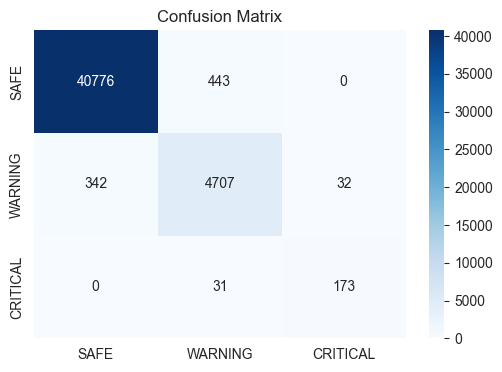

--- HISTORY ---
Epoch  | Tr.Loss  | Val.Loss | Prec. (S, W, C)    | Rec. (S, W, C)     | F1 (S, W, C)      
-----------------------------------------------------------------------------------------------
0      | 0.467    | 0.141    | (0.99, 0.62, 0.43) | (0.97, 0.76, 0.69) | (0.98, 0.68, 0.53)
1      | 0.324    | 0.072    | (0.98, 0.88, 0.73) | (0.99, 0.73, 0.79) | (0.99, 0.80, 0.76)
2      | 0.241    | 0.054    | (0.99, 0.91, 0.76) | (1.00, 0.80, 0.77) | (0.99, 0.85, 0.76)
3      | 0.211    | 0.055    | (0.98, 0.89, 0.77) | (0.99, 0.79, 0.59) | (0.99, 0.84, 0.66)
4      | 0.199    | 0.051    | (0.98, 0.92, 0.69) | (1.00, 0.78, 0.80) | (0.99, 0.84, 0.74)
5      | 0.190    | 0.045    | (0.99, 0.92, 0.70) | (1.00, 0.81, 0.76) | (0.99, 0.86, 0.73)
6      | 0.186    | 0.045    | (0.99, 0.94, 0.70) | (1.00, 0.80, 0.82) | (0.99, 0.86, 0.76)
7      | 0.181    | 0.047    | (0.99, 0.93, 0.78) | (1.00, 0.80, 0.72) | (0.99, 0.86, 0.74)
8      | 0.179    | 0.043    | (0.99, 0.90, 0.72) | (0.99, 0

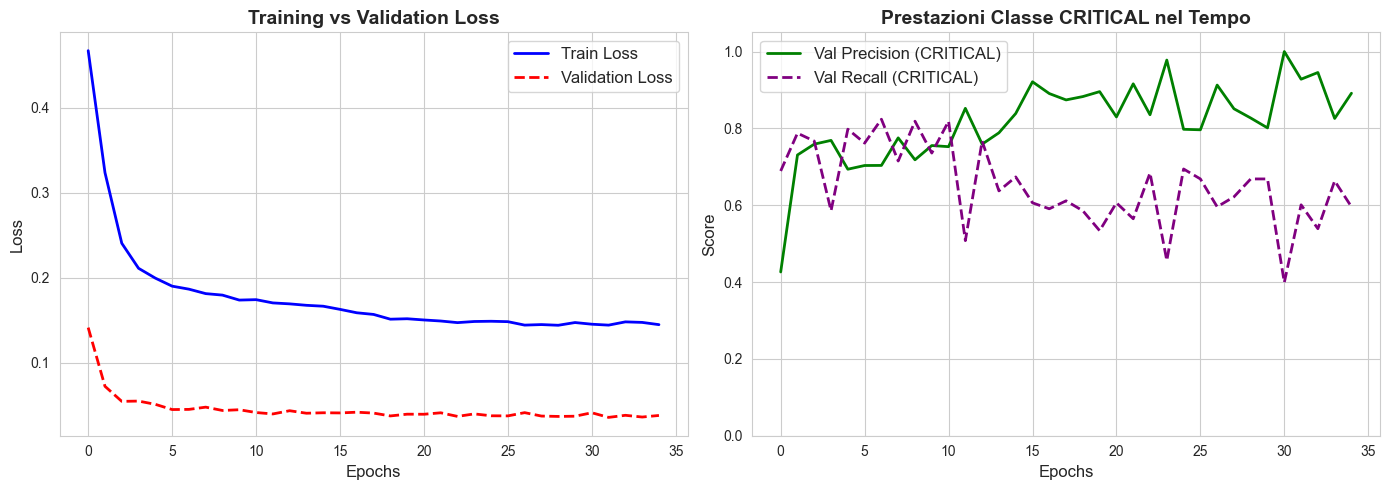

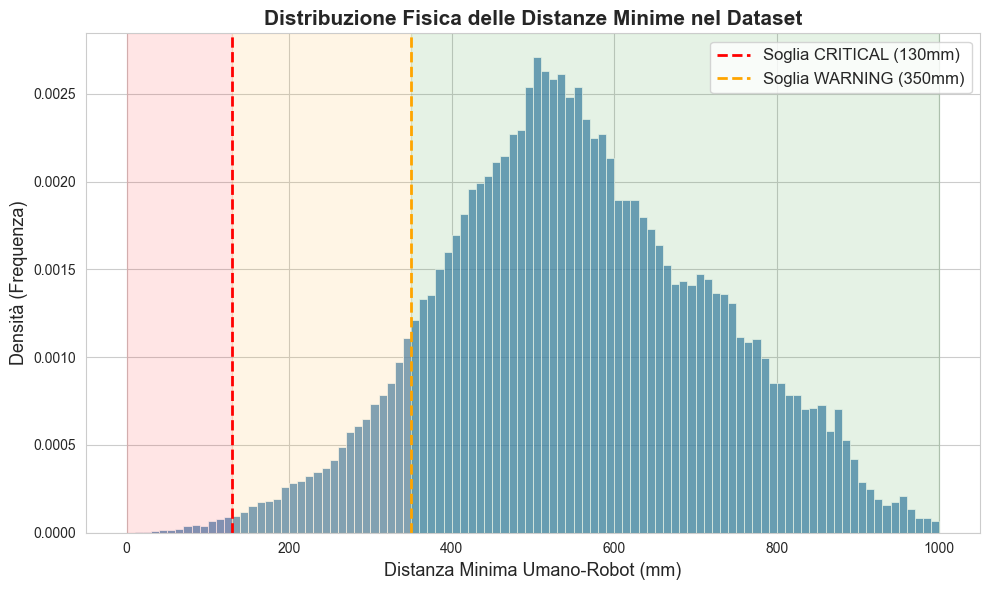

In [16]:
import sys
import os

# Calcola il percorso della cartella genitore (la root del progetto)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Aggiunge la cartella genitore ai percorsi in cui Python cerca i moduli
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
from src.plots import plot_learning_curves, plot_distance_distribution

training_history = static_trainer.train()

plot_learning_curves(training_history)

plot_distance_distribution(static_dataset)